In [1]:
!pip -q install h5py plotly >/dev/null 2>&1

In [2]:
import os, glob, time, zipfile, urllib.request, ssl
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import h5py
from google.colab import drive

drive.mount('/content/drive')
DRIVE_MODEL_DIR = '/content/drive/MyDrive/PointNet_Models'
os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)

Mounted at /content/drive


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = (device.type == 'cuda')
print('device:', device, '| AMP:', USE_AMP, '| torch', torch.__version__)

device: cuda | AMP: True | torch 2.11.0+cu128


In [4]:
NUM_CLASSES=13
CLASS_NAMES = ['ceiling','floor','wall','beam','column','window','door',
               'table','chair','sofa','bookcase','board','clutter']

def seed_all(s=42):
  np.random.seed(s)
  torch.manual_seed(s)
  if torch.cuda.is_available():
    torch.cuda.manual_seed_all(s)
seed_all()

In [5]:
!kaggle datasets download -d bhargavrko619/indoor3d-sem-seg-hdf5-data

Dataset URL: https://www.kaggle.com/datasets/bhargavrko619/indoor3d-sem-seg-hdf5-data
License(s): unknown
100% 1.57G/1.57G [01:13<00:00, 22.8MB/s]



In [6]:
DATA_DIR = 'indoor3d_sem_seg_hdf5_data'
ZIP = 'indoor3d-sem-seg-hdf5-data.zip'
print('Extracting...')
with zipfile.ZipFile(ZIP) as z:
  z.extractall('.')
if not os.path.isdir(DATA_DIR):
    cand = glob.glob('**/all_files.txt', recursive=True)
    if cand: DATA_DIR = os.path.dirname(cand[0])
print('Data dir:', DATA_DIR, '| files:', len(glob.glob(os.path.join(DATA_DIR,'*.h5'))))

Extracting...
Data dir: indoor3d_sem_seg_hdf5_data | files: 24


In [7]:
TEST_AREA = 5
MAX_TRAIN_BLOCKS = None

with open(os.path.join(DATA_DIR,'all_files.txt')) as f:
  h5_list = [os.path.join(DATA_DIR, os.path.basename(l.strip())) for l in f if l.strip()]
with open(os.path.join(DATA_DIR, 'room_filelist.txt')) as f:
  room_list = [l.strip() for l in f if l.strip()]

data_chunks, label_chunks = [], []
for fp in h5_list:
  with h5py.File(fp, 'r') as h:
    data_chunks.append(h['data'][:].astype(np.float32))   # (n,4096,9)
    label_chunks.append(h['label'][:].astype(np.uint8))   # (n,4096)
ALL_DATA = np.concatenate(data_chunks, axis=0)
ALL_LABELS = np.concatenate(label_chunks, axis=0)
del data_chunks, label_chunks
print('All blocks:', ALL_DATA.shape, '| labels:', ALL_LABELS.shape,
      '| ~%.1f GB' % (ALL_DATA.nbytes/1e9))

area_of_block = np.array([int(r.split('_')[1]) for r in room_list])
assert len(area_of_block) == len(ALL_DATA), 'block/room mismatch'
train_idx = np.where(area_of_block != TEST_AREA)[0]
test_idx  = np.where(area_of_block == TEST_AREA)[0]
if MAX_TRAIN_BLOCKS:
    rng = np.random.default_rng(0)
    train_idx = rng.choice(train_idx, size=min(MAX_TRAIN_BLOCKS,len(train_idx)), replace=False)
print(f'train blocks: {len(train_idx)} | test blocks (Area {TEST_AREA}): {len(test_idx)}')


All blocks: (23585, 4096, 9) | labels: (23585, 4096) | ~3.5 GB
train blocks: 16733 | test blocks (Area 5): 6852


In [8]:
# --- Dataset: feature selection, sampling, per-block xyz centering ---
# The 9 channels are [x,y,z, r,g,b, x_room,y_room,z_room].
FEATURES = {
    'xyz' : [0, 1, 2],                      #geometry only, 3 channels
    'xyzrgb' : [0, 1, 2, 3, 4, 5],          #geometry + colour, 6 ch
    'xyz_norm' : [0, 1, 2, 6, 7, 8],        #geometry only +  Normalized coordinates relative to the boundaries of the entire room, 6ch (local + global with no color)
    'full' : [0, 1, 2, 3, 4, 5, 6, 7, 8],   #all
}

class S3DISBlocks(Dataset):
  def __init__(self, indices, npoints=4096, feature='full', train=True):
        self.idx = indices
        self.np = npoints
        self.fidx = FEATURES[feature]
        self.train = train

  def __len__(self):
    return len(self.idx)

  def _sample(self, n, i):
        if self.np >= n:
            ch = np.random.choice(n, self.np, replace=True)
        elif self.train:
            ch = np.random.choice(n, self.np, replace=False)
        else:
            ch = np.random.default_rng(i).choice(n, self.np, replace=False)
        return ch

  def __getitem__(self, k):
        bi = self.idx[k]
        block = ALL_DATA[bi]                      # (4096, 9)
        lbl   = ALL_LABELS[bi]                     # (4096,)
        ch = self._sample(block.shape[0], bi)
        pts = block[ch].copy()
        if self.train:
            pts = self._augment(pts)
        lbl = lbl[ch].astype(np.int64)
        pts[:, 0:3] -= pts[:, 0:3].mean(0)        # normalisation
        feat = pts[:, self.fidx].T
        return torch.from_numpy(feat).float(), torch.from_numpy(lbl)

  def _augment(self, pts):
    theta = np.random.uniform(0, 2*np.pi)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c,-s,0],[s,c,0],[0,0,1]], dtype=np.float32)
    pts[:, 0:3] = pts[:, 0:3] @ R.T
    pts[:, 0:3] *= np.random.uniform(0.8, 1.25)
    pts[:, 0:3] += np.clip(0.01*np.random.randn(*pts[:, 0:3].shape), -0.05, 0.05).astype(np.float32)
    if np.random.rand() < 0.2:
        pts[:, 3:6] = 0.0
    return pts


def make_loaders(npoints=4096, feature='full', batch=24):
    tr = S3DISBlocks(train_idx, npoints, feature, train=True)
    te = S3DISBlocks(test_idx,  npoints, feature, train=False)
    return (DataLoader(tr, batch, shuffle=True,  num_workers=2, pin_memory=True, drop_last=True, persistent_workers=True),
            DataLoader(te, batch, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True))

xb, yb = S3DISBlocks(train_idx, 4096, 'full')[0]
print('sample feat:', tuple(xb.shape), '| labels:', tuple(yb.shape))


sample feat: (9, 4096) | labels: (4096,)


In [9]:
# --- PointNet for segmentation (with T-Net input + feature transforms) ---
# A 1x1 Conv over (B, C, N) is a per-point ("shared") MLP.
# 2 T-Nets (small sub-networks that regress a
# transformation matrix) -- an input transform on the raw point
# features and a feature transform on the 64-d local features. forward()
# returns (logits, feat_transform); the feature transform feeds the
# orthogonality regularizer added to the loss.

class TNet(nn.Module):
    """Mini-PointNet that regresses a (k x k) transformation matrix, init ~ identity."""
    def __init__(self, k):
        super().__init__()
        self.k = k
        self.conv1 = nn.Conv1d(k, 64, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 1024, 1)
        self.bn3 = nn.BatchNorm1d(1024)
        self.fc1 = nn.Linear(1024, 512)
        self.bn4 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn5 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, k * k)
        nn.init.zeros_(self.fc3.weight)
        nn.init.zeros_(self.fc3.bias)  # start as I

    def forward(self, x):                       # x: (B, k, N)
        B = x.size(0)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = torch.max(x, dim=2)[0]              # (B, 1024) global descriptor
        x = F.relu(self.bn4(self.fc1(x)))
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x)                         # (B, k*k)
        x = x + torch.eye(self.k, device=x.device).flatten()
        return x.view(B, self.k, self.k)

class PointNetSeg(nn.Module):
    """Vanilla PointNet + T-Nets for per-point semantic segmentation.
    in_channels : 3 / 6 / 9 ;  use_global=False -> ablation.
    Input (B, C, N) -> returns (logits (B, num_classes, N), feat_transform (B, 64, 64))."""
    def __init__(self, num_classes=NUM_CLASSES, in_channels=9, use_global=True):
        super().__init__()
        self.use_global = use_global

        self.input_tnet = TNet(in_channels)      #input transform
        self.feat_tnet  = TNet(64)               #feature transform

        # 1) local features (in -> 64 -> 64)
        self.conv1 = nn.Conv1d(in_channels, 64, 1)
        self.conv2 = nn.Conv1d(64, 64, 1)
        self.bn1   = nn.BatchNorm1d(64)
        self.bn2   = nn.BatchNorm1d(64)
        # 2) lift to 1024 for the global max-pool (64 -> 128 -> 1024)
        self.conv3 = nn.Conv1d(64, 64, 1)
        self.conv4 = nn.Conv1d(64, 128, 1)
        self.conv5 = nn.Conv1d(128, 1024, 1)
        self.bn3   = nn.BatchNorm1d(64)
        self.bn4   = nn.BatchNorm1d(128)
        self.bn5   = nn.BatchNorm1d(1024)
        # 3) segmentation head on concat [local | global]
        seg_in = 64 + (1024 if use_global else 0)
        self.conv6 = nn.Conv1d(seg_in, 512, 1)
        self.conv7 = nn.Conv1d(512, 256, 1)
        self.conv8 = nn.Conv1d(256, 128, 1)
        self.bn6   = nn.BatchNorm1d(512)
        self.bn7   = nn.BatchNorm1d(256)
        self.bn8   = nn.BatchNorm1d(128)
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Conv1d(128, num_classes, 1)

    def forward(self, x):
        B, C, N = x.shape

        # --- input transform: align the raw point features ---
        T_in = self.input_tnet(x)                # (B, C, C)
        x = torch.bmm(T_in, x)                   # (B, C, N)  each point: T_in @ feature

        # --- per-point local features ---
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))      # (B, 64, N)

        # --- feature transform: align the 64-d feature space ---
        T_feat = self.feat_tnet(x)               # (B, 64, 64)
        x = torch.bmm(T_feat, x)                 # (B, 64, N)
        local_feat = x                           # used for skip-concat below

        # --- expand, then max-pool over points -> global vector ---
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))      # (B, 1024, N)
        if self.use_global:
            g = torch.max(x, dim=2, keepdim=True)[0].repeat(1, 1, N)   # (B,1024,N)
            x = torch.cat([local_feat, g], dim=1)                      # (B,1088,N)
        else:
            x = local_feat

        # --- per-point classification ---
        x = F.relu(self.bn6(self.conv6(x)))
        x = F.relu(self.bn7(self.conv7(x)))
        x = F.relu(self.bn8(self.conv8(x)))
        x = self.dropout(x)
        x = self.classifier(x)                   # (B, num_classes, N)
        return x, T_feat

print('params (full/9ch, global):', sum(p.numel() for p in PointNetSeg().parameters())/1e6, 'M')

params (full/9ch, global): 3.556638 M


In [10]:
# --- metrics (confusion matrix -> OA, mAcc, mIoU, per-class IoU) ---
class SegMetrics:
  def __init__(self, k=NUM_CLASSES):
    self.k = k
    self.cm = np.zeros((k, k), dtype=np.int64)

  def update(self, pred, target):
    pred = pred.reshape(-1)
    target = target.reshape(-1)
    m = (target >= 0) & (target < self.k)
    self.cm += np.bincount(self.k*target[m]+pred[m], minlength=self.k**2).reshape(self.k,self.k)

  def compute(self):
    cm = self.cm.astype(np.float64)
    tp = np.diag(cm)
    oa = tp.sum()/cm.sum().clip(min=1)
    acc = tp/cm.sum(1).clip(min=1)
    iou = tp/(cm.sum(1)+cm.sum(0)-tp).clip(min=1)
    seen = cm.sum(1)>0
    return {'OA':oa, 'mAcc':acc[seen].mean(), 'mIoU':iou[seen].mean(), 'per_class_iou':iou}

def class_weights():
    counts = np.bincount(ALL_LABELS[train_idx].reshape(-1), minlength=NUM_CLASSES).astype(np.float64)
    median_freq = np.median(counts)
    w = median_freq / counts.clip(min=1)
    w = np.log1p(w)
    w = w / w.sum() * NUM_CLASSES
    return torch.tensor(w, dtype=torch.float32, device=device)

W = class_weights()
print('class weights:', np.round(W.cpu().numpy(), 2))


class weights: [0.16 0.17 0.22 1.09 1.44 1.78 0.69 0.86 0.61 2.57 0.88 2.21 0.32]


In [11]:
# --- extra loss terms: feature-transform regularizer + Lovasz-softmax (IoU surrogate) ---
# REG_W keeps the 64x64 feature transform close to orthogonal.
# Lovasz-softmax directly optimizes IoU, which helps the rare/hard classes.
REG_W    = 1e-3
LOVASZ_W = 1.0

def feature_transform_regularizer(trans):
    B, k, _ = trans.shape
    I = torch.eye(k, device=trans.device).unsqueeze(0)
    diff = torch.bmm(trans, trans.transpose(1, 2)) - I
    return torch.mean(torch.norm(diff.reshape(B, -1), dim=1))

def _lovasz_grad(gt_sorted):
    p = len(gt_sorted)
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1.0 - intersection / union
    if p > 1:
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
    return jaccard

def lovasz_softmax(probas, labels):
    # probas: (B, C, N) softmax probabilities ; labels: (B, N)
    B, C, N = probas.shape
    probas = probas.permute(0, 2, 1).reshape(-1, C)
    labels = labels.reshape(-1)
    losses = []
    for c in range(C):
        fg = (labels == c).float()
        if fg.sum() == 0:
            continue
        errors = (fg - probas[:, c]).abs()
        errors_sorted, perm = torch.sort(errors, 0, descending=True)
        losses.append(torch.dot(errors_sorted, _lovasz_grad(fg[perm])))
    if not losses:
        return probas.sum() * 0.0
    return torch.stack(losses).mean()

In [12]:
# --- train / eval loops  ---

from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm


@torch.no_grad()
def evaluate(model, loader):
  model.eval()
  met = SegMetrics()
  for x, y in loader:
    x = x.to(device, non_blocking=True)
    with autocast('cuda', enabled=USE_AMP):
      out, _ = model(x)
    pred = out.argmax(1).cpu().numpy()
    met.update(pred, y.numpy())
  return met.compute()

def train_model(model, tr_loader, te_loader, epochs=20, lr=1e-3, weighted=True, log=True):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    warmup_epochs = 3
    def lr_lambda(ep):
        if ep < warmup_epochs:
            return (ep+1) / warmup_epochs
        return 0.5 * (1 + np.cos(np.pi * (ep - warmup_epochs) / (epochs - warmup_epochs)))
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)
    scaler = GradScaler('cuda', enabled=USE_AMP)
    crit = nn.CrossEntropyLoss(weight=W if weighted else None, label_smoothing=0.05)
    hist = []

    epoch_bar = tqdm(range(epochs), desc='Training', unit='epoch')
    for ep in epoch_bar:
        model.train(); t0 = time.time(); run = 0.0

        batch_bar = tqdm(tr_loader, desc=f'Epoch {ep+1}/{epochs}',
                         leave=False, unit='batch')
        for x, y in batch_bar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast('cuda', enabled=USE_AMP):
                logits, t_feat = model(x)
                loss = crit(logits, y)                             # weighted CE + label smoothing
                loss = loss + LOVASZ_W * lovasz_softmax(F.softmax(logits.float(), dim=1), y)   #IoU loss
                loss = loss + REG_W * feature_transform_regularizer(t_feat.float())            #T-Net reg
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            run += loss.item()
            batch_bar.set_postfix(loss=f'{loss.item():.3f}')
        batch_bar.close()

        sched.step()
        m = evaluate(model, te_loader); hist.append(m)
        avg_loss = run / len(tr_loader)

        epoch_bar.set_postfix(
            loss=f'{avg_loss:.3f}',
            OA=f'{m["OA"]:.3f}',
            mIoU=f'{m["mIoU"]:.3f}'
        )
        if log:
            print(f'ep {ep+1:02d}/{epochs} | loss {avg_loss:.3f} '
                  f'| OA {m["OA"]:.3f} mAcc {m["mAcc"]:.3f} mIoU {m["mIoU"]:.3f} '
                  f'| {time.time()-t0:.0f}s')
    return model, hist

In [13]:
# --- MAIN RUN: full 9-channel input, global features on ---
EPOCHS = 30
TRAIN_NEW_MODEL = True

tr_loader, te_loader = make_loaders(npoints=4096, feature='full', batch=24)
model = PointNetSeg(in_channels=9, use_global=True)

if TRAIN_NEW_MODEL:
    model, hist = train_model(model, tr_loader, te_loader, epochs=EPOCHS)
    final = hist[-1]
    final_loss = sum(1 for _ in [])

    model.eval()
    crit = nn.CrossEntropyLoss(weight=W)
    running_loss = 0.0
    with torch.no_grad():
        for x, y in tr_loader:
            x = x.to(device); y = y.to(device)
            running_loss += crit(model(x)[0], y).item()
    avg_loss = running_loss / len(tr_loader)

    # Save to Drive
    save_name = f'pointnet_s3dis_ep{EPOCHS}_loss{avg_loss:.4f}.pt'
    save_path = os.path.join(DRIVE_MODEL_DIR, save_name)
    torch.save(model.state_dict(), save_path)
    print(f'\nModel saved to: {save_path}')

else:
    saved_models = sorted(glob.glob(os.path.join(DRIVE_MODEL_DIR, 'pointnet_s3dis_*.pt')))
    assert len(saved_models) > 0, f'No saved models found in {DRIVE_MODEL_DIR}!'
    load_path = saved_models[-1]
    model.load_state_dict(torch.load(load_path, map_location=device))
    model.to(device)
    print(f'Loaded pre-trained model from: {load_path}')
    hist = [evaluate(model, te_loader)]

final = hist[-1]
print('\nFINAL (Area 5):',
      {k: round(float(v),4) for k,v in final.items() if k!='per_class_iou'})
print('\nPer-class IoU:')
for c, i in zip(CLASS_NAMES, final['per_class_iou']):
    print(f'  {c:10s} {i:.3f}')


Training:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1/30:   0%|          | 0/697 [00:00<?, ?batch/s]

ep 01/30 | loss 2.675 | OA 0.719 mAcc 0.426 mIoU 0.302 | 112s


Epoch 2/30:   0%|          | 0/697 [00:00<?, ?batch/s]

ep 02/30 | loss 2.416 | OA 0.718 mAcc 0.489 mIoU 0.322 | 110s


...

ep 28/30 | loss 1.361 | OA 0.835 mAcc 0.576 mIoU 0.463 | 111s


Epoch 29/30:   0%|          | 0/697 [00:00<?, ?batch/s]

ep 29/30 | loss 1.363 | OA 0.835 mAcc 0.581 mIoU 0.461 | 111s


Epoch 30/30:   0%|          | 0/697 [00:00<?, ?batch/s]

ep 30/30 | loss 1.351 | OA 0.835 mAcc 0.580 mIoU 0.464 | 110s

Model saved to: /content/drive/MyDrive/PointNet_Models/pointnet_s3dis_ep30_loss0.3780.pt

FINAL (Area 5): {'OA': 0.8348, 'mAcc': 0.5801, 'mIoU': 0.4643}

Per-class IoU:
  ceiling    0.903
  floor      0.979
  wall       0.723
  beam       0.001
  column     0.112
  window     0.446
  door       0.180
  table      0.610
  chair      0.577
  sofa       0.182
  bookcase   0.515
  board      0.381
  clutter    0.426


In [16]:
# --- visualise ground truth vs prediction for one test block ---
import plotly.graph_objects as go
from plotly.subplots import make_subplots

PALETTE = ['#9e9e9e','#8d6e63','#bdbdbd','#5d4037','#7e57c2','#42a5f5','#26a69a',
           '#ef5350','#66bb6a','#ffa726','#ab47bc','#ec407a','#cfd8dc']

def show_block(model, block_pos=0, npoints=4096):
    model.eval()
    bi = test_idx[block_pos]
    blk = ALL_DATA[bi].copy(); lbl = ALL_LABELS[bi].astype(int)
    xyz = blk[:, :3].copy()
    feat = blk.copy(); feat[:, :3] -= feat[:, :3].mean(0)
    x = torch.from_numpy(feat.T[None]).float().to(device)
    with torch.no_grad(), autocast('cuda', enabled=USE_AMP):
        pred = model(x)[0].argmax(1)[0].cpu().numpy()

    fig = make_subplots(rows=1, cols=2, specs=[[{'type':'scatter3d'},{'type':'scatter3d'}]],
                        subplot_titles=('Ground truth','Prediction'))
    for col, lab in [(1,lbl),(2,pred)]:
        fig.add_trace(go.Scatter3d(
            x=xyz[:,0], y=xyz[:,1], z=xyz[:,2], mode='markers',
            marker=dict(size=1.6, color=[PALETTE[c] for c in lab]),
            text=[CLASS_NAMES[c] for c in lab], hoverinfo='text', showlegend=False), 1, col)
    fig.update_layout(height=520, width=980, margin=dict(l=0,r=0,t=30,b=0))
    fig.show()
    acc = (pred==lbl).mean()
    print(f'block {block_pos} point accuracy: {acc:.3f}')

show_block(model, block_pos=0)

block 0 point accuracy: 0.619


Evaluating:   0%|          | 0/286 [00:00<?, ?batch/s]

  Overall Accuracy (OA)  : 0.8350
  Mean Accuracy (mAcc)   : 0.5817
  Mean IoU (mIoU)        : 0.4635

Class             IoU   Accuracy    Support
------------------------------------------
ceiling         0.905      0.939  7,225,469
floor           0.979      0.995  6,635,733
wall            0.724      0.878  5,604,167
beam            0.002      0.104      6,095
column          0.106      0.147    317,312
window          0.447      0.658    501,952
door            0.180      0.219    689,546
table           0.609      0.754  1,267,637
chair           0.575      0.767    743,087
sofa            0.171      0.241     95,466
bookcase        0.513      0.639  1,987,512
board           0.387      0.628    195,602
clutter         0.427      0.593  2,796,214


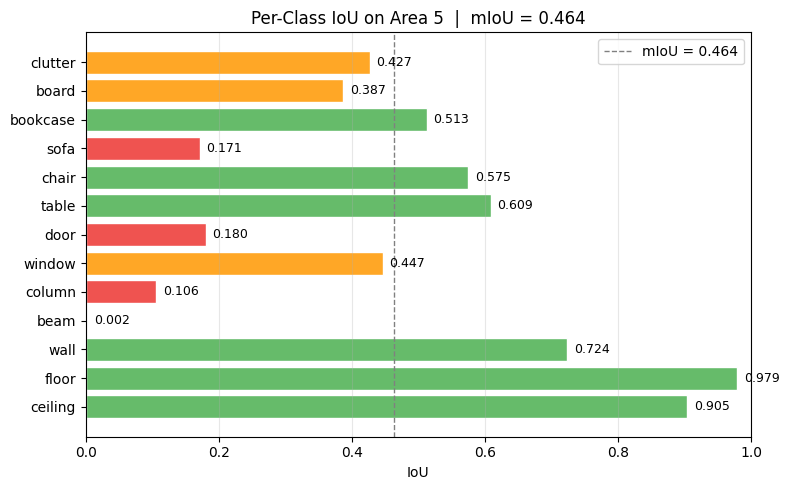

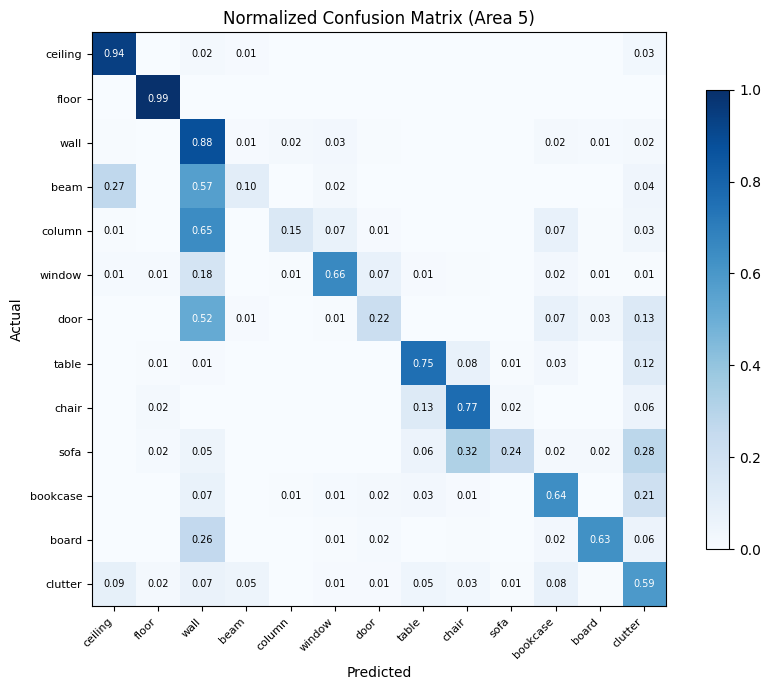

In [17]:
# --- Detailed Model Evaluation using SegMetrics ---
import matplotlib.pyplot as plt

model.eval()
met = SegMetrics()

with torch.no_grad():
    for x, y in tqdm(te_loader, desc='Evaluating', unit='batch'):
        x = x.to(device, non_blocking=True)
        with autocast('cuda', enabled=USE_AMP):
            out, _ = model(x)               # logits only
        pred = out.argmax(1).cpu().numpy()
        met.update(pred, y.numpy())

results = met.compute()

# --- Print Summary Metrics ---
print('=' * 50)
print(f'  Overall Accuracy (OA)  : {results["OA"]:.4f}')
print(f'  Mean Accuracy (mAcc)   : {results["mAcc"]:.4f}')
print(f'  Mean IoU (mIoU)        : {results["mIoU"]:.4f}')
print('=' * 50)

# --- Print Per-Class Table ---
print(f'\n{"Class":<12} {"IoU":>8} {"Accuracy":>10} {"Support":>10}')
print('-' * 42)
cm = met.cm
for i, name in enumerate(CLASS_NAMES):
    iou_i = results['per_class_iou'][i]
    acc_i = cm[i, i] / max(cm[i].sum(), 1)
    support = cm[i].sum()
    print(f'{name:<12} {iou_i:>8.3f} {acc_i:>10.3f} {support:>10,}')

# --- Plot Per-Class IoU as a Horizontal Bar Chart ---
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#ef5350' if v < 0.3 else '#ffa726' if v < 0.5 else '#66bb6a'
          for v in results['per_class_iou']]
bars = ax.barh(CLASS_NAMES, results['per_class_iou'], color=colors, edgecolor='white')
ax.set_xlim(0, 1.0)
ax.set_xlabel('IoU')
ax.set_title(f'Per-Class IoU on Area 5  |  mIoU = {results["mIoU"]:.3f}')
ax.axvline(x=results['mIoU'], color='gray', linestyle='--', linewidth=1, label=f'mIoU = {results["mIoU"]:.3f}')
for bar, val in zip(bars, results['per_class_iou']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

# --- Plot Confusion Matrix Heatmap ---
fig, ax = plt.subplots(figsize=(9, 7))
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True).clip(min=1)  # row-normalized
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Normalized Confusion Matrix (Area 5)')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        val = cm_norm[i, j]
        if val > 0.005:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if val > 0.5 else 'black')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()
